### Mashiur Rahman

# Project 4 — Discover Groups in Handwritten Digits

## Part 1 — Explore the Images

### Import Required Library 

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [13]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target

print("Number of images:", X.shape[0])
print("Number of features:", X.shape[1])
print("Data type:", X.dtype)
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Number of images: 70000
Number of features: 784
Data type: int64
Minimum pixel value: 0
Maximum pixel value: 255


### Display Sample Images

Each row contains 784 pixel values. Reshaping a row to 28 × 28 lets us see the handwritten digit.

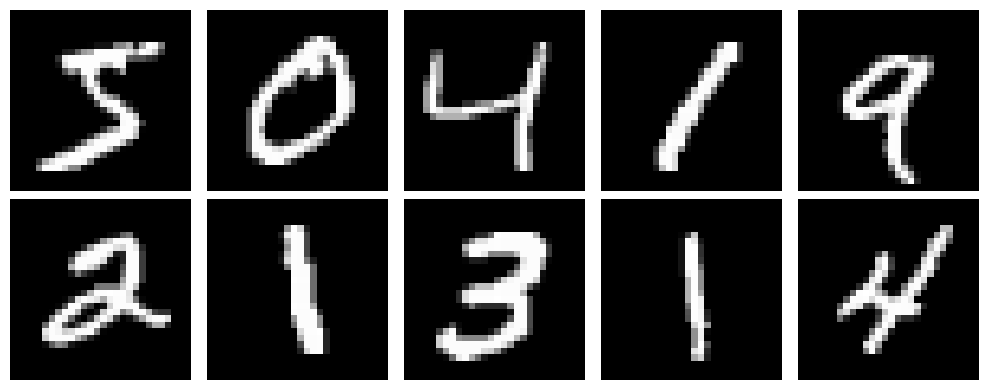

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Normalize Pixel Values

In [5]:
X = X / 255.0

print("Minimum after normalization:", X.min())
print("Maximum after normalization:", X.max())

Minimum after normalization: 0.0
Maximum after normalization: 1.0


### Part 1 Answers

1. **How many images are in the dataset?**  
   MNIST contains 70,000 images.

2. **Why does each image have 784 features?**  
   Each image is 28 × 28 pixels. When it is flattened into one row, it has 28 × 28 = 784 pixel values.

3. **What do the pixel values represent?**  
   They represent the brightness of each pixel. Before normalization, the values range from 0 to 255.

4. **Why do images of the same digit look different?**  
   People write digits in different shapes, sizes, positions, and line thicknesses.

5. **Why do we normalize the pixel values?**  
   Normalization changes the range from 0–255 to 0–1. This gives K-Means consistently scaled pixel values to work with.

## Part 2 — Discover Groups Using K-Means

K-Means groups images based on their pixel values without knowing which digits they show.

In [7]:
rng = np.random.RandomState(42)
sample_indices = rng.choice(len(X), size=10000, replace=False)

X_sample = X[sample_indices]
y_sample = y[sample_indices]  # Save for Part 4; do not use to train K-Means

print("Images in sample:", len(X_sample))
print("Features per image:", X_sample.shape[1])

Images in sample: 10000
Features per image: 784


### Compare Different Numbers of Clusters

I will compare K = 5, 10, and 15 using the elbow method. Inertia measures how far images are from the centers of their assigned clusters.

#### Calculate inertia

In [9]:
k_values = [5, 10, 15]
inertia = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_sample)
    inertia.append(model.inertia_)
    print("K =", k, "| Inertia =", round(model.inertia_, 2))

K = 5 | Inertia = 432527.75
K = 10 | Inertia = 390343.06
K = 15 | Inertia = 365525.23


#### Plot the elbow chart

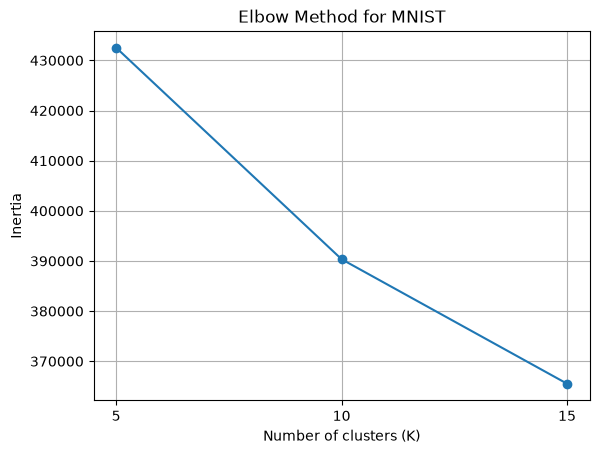

In [14]:
plt.plot(k_values, inertia, marker="o")
plt.xticks(k_values)
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for MNIST")
plt.grid(True)
plt.show()

Inertia should decrease as K increases. With only three values, the chart may not show a sharp elbow. K = 10 is a reasonable choice because the dataset contains ten digits, but K-Means has not been told those digit labels.

### Train the Final K-Means Model

In [15]:
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_sample)

print("Number of cluster assignments:", len(clusters))

Number of cluster assignments: 10000


#### Check cluster sizes

In [17]:
cluster_sizes = pd.Series(clusters).value_counts().sort_index()

display(cluster_sizes)
print("Total images:", cluster_sizes.sum())
print("Smallest cluster:", cluster_sizes.min())
print("Largest cluster:", cluster_sizes.max())

0     519
1     757
2    1487
3    1039
4    1475
5    1331
6     513
7     906
8    1017
9     956
Name: count, dtype: int64

Total images: 10000
Smallest cluster: 513
Largest cluster: 1487


### Part 2 Answers

1. **Which value of K did you choose?**  
   I chose K = 10.

2. **Why did you choose it?**  
I compared K = 5, 10, and 15 using an elbow plot. I chose 10 as a reasonable value because MNIST contains ten types of handwritten digits. The model was not given the digit labels during training.

3. **How many images are in each cluster?**  
Cluster 0 has 519 images; cluster 1 has 757; cluster 2 has 1,487; cluster 3 has 1,039; cluster 4 has 1,475; cluster 5 has 1,331; cluster 6 has 513; cluster 7 has 906; cluster 8 has 1,017; and cluster 9 has 956. Together, the clusters contain 10,000 images.

4. **Are the clusters approximately the same size?**  
No. The smallest cluster has 513 images, while the largest has 1,487—almost three times as many. K-Means does not require the clusters to have equal sizes.

## Part 3 — Understand the Clusters

A centroid is the average image for a cluster. I will display all ten centroids and some individual images to see whether the groups look similar.

#### Display all cluster centroids

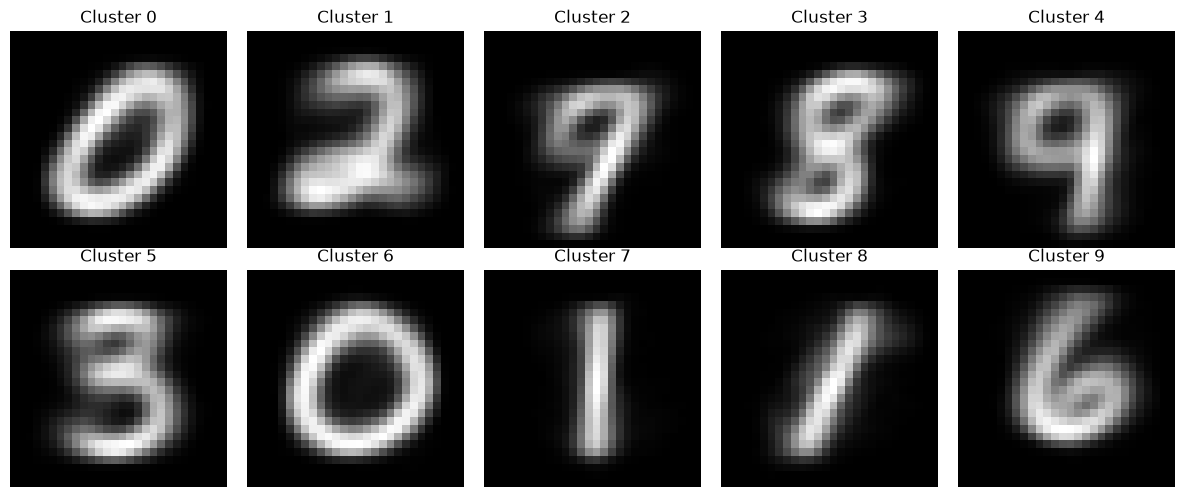

In [18]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(12, 5))

for cluster_number in range(10):
    plt.subplot(2, 5, cluster_number + 1)
    plt.imshow(centroids[cluster_number].reshape(28, 28), cmap="gray")
    plt.title(f"Cluster {cluster_number}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### View Individual Images in Each Cluster

I will display five images from each cluster to check whether they look similar to one another and to their centroid.

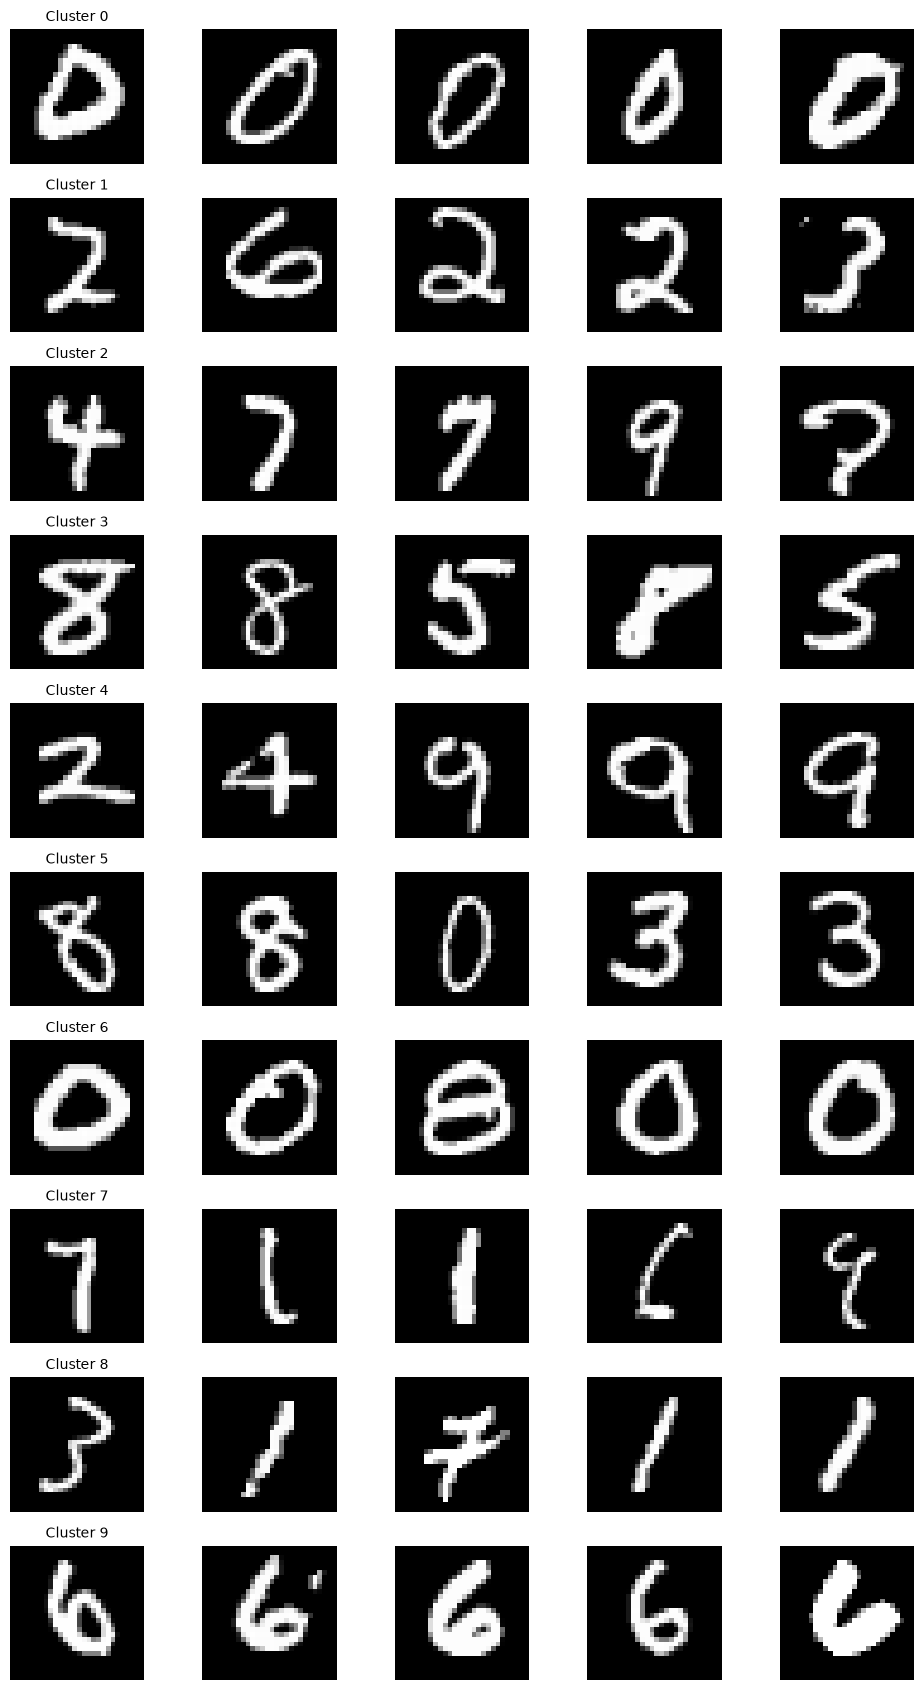

In [19]:
plt.figure(figsize=(10, 17))

for cluster_number in range(10):
    image_positions = np.where(clusters == cluster_number)[0][:5]

    for column, position in enumerate(image_positions):
        plt.subplot(10, 5, cluster_number * 5 + column + 1)
        plt.imshow(X_sample[position].reshape(28, 28), cmap="gray")
        plt.axis("off")

        if column == 0:
            plt.title(f"Cluster {cluster_number}", fontsize=10)

plt.tight_layout()
plt.show()

### Part 3 Answers

1. **Do images within the same cluster look similar?**  
Some do. For example, the five images in cluster 0 all look like handwritten 0s, and the five in cluster 9 look like 6s. Other clusters contain different-looking images. Cluster 3 includes shapes that look like both 8 and 5.

2. **Does a cluster appear to contain mostly one digit?**  
Some appear to. In the five examples shown, cluster 0 looks mainly like 0, cluster 6 also looks mainly like 0, and cluster 9 looks mainly like 6. Five examples are not enough to establish what is most common in an entire cluster, so I will check the actual labels in Part 4.

3. **Are some digits spread across multiple clusters?**  
Yes, this appears to happen. Images resembling 0 appear in both clusters 0 and 6. Images resembling 1 appear in clusters 7 and 8. K-Means can group different writing styles of the same digit separately.

4. **Which digits appear difficult for K-Means to separate?**  
The sample images suggest that 5 and 8 can be mixed in cluster 3. Clusters 1, 2, 4, and 5 also contain several different-looking digit shapes. The Part 4 table will show more reliably which actual digits are mixed.

## Part 4 — Compare Clusters with the Actual Digit Labels

I will compare each K-Means cluster with the actual digit labels. The labels are used only to interpret the completed clusters.

In [20]:
comparison = pd.crosstab(
    pd.Series(clusters, name="Cluster"),
    pd.Series(y_sample, name="Actual digit")
)

display(comparison)

Actual digit,0,1,2,3,4,5,6,7,8,9
Cluster,,,,,,,,,,
0,427,0,11,17,0,39,14,1,7,3
1,5,1,666,42,8,4,10,9,12,0
2,4,1,8,7,290,57,1,654,23,442
3,22,2,20,146,4,266,9,1,560,9
4,3,4,26,33,500,63,14,295,34,503
5,31,5,71,700,0,310,4,0,197,13
6,458,0,5,2,2,5,26,2,6,7
7,0,642,45,55,16,18,34,34,32,30
8,2,497,70,24,49,155,48,57,87,28


### Find the Most Common Digit in Each Cluster

In [21]:
cluster_summary = pd.DataFrame({
    "Cluster size": comparison.sum(axis=1),
    "Most common digit": comparison.idxmax(axis=1),
    "Count of most common digit": comparison.max(axis=1)
})

cluster_summary["Percentage"] = (
    cluster_summary["Count of most common digit"]
    / cluster_summary["Cluster size"] * 100
).round(1)

display(cluster_summary)

,Cluster size,Most common digit,Count of most common digit,Percentage
Cluster,,,,
0,519,0,427,82.3
1,757,2,666,88.0
2,1487,7,654,44.0
3,1039,8,560,53.9
4,1475,9,503,34.1
5,1331,3,700,52.6
6,513,0,458,89.3
7,906,1,642,70.9
8,1017,1,497,48.9


### Part 4 Answers

1. **Does each cluster mainly contain one digit?**  
   No. Some clusters contain a clear majority of one digit. For example, cluster 6 contains 458 images of digit 0 out of 513 images (89.3%), and cluster 1 contains 666 images of digit 2 out of 757 (88.0%). Other clusters are mixed. In cluster 4, the most common digit is 9, but it accounts for only 503 of 1,475 images (34.1%).

2. **Which digits are grouped together?**  
   Cluster 4 groups many 9s (503), 4s (500), and 7s (295). Cluster 2 contains many 7s (654), 9s (442), and 4s (290). Cluster 3 contains many 8s (560) and 5s (266). These results show that some differently labelled digits have pixel patterns that K-Means groups together.

3. **Which digits appear in multiple clusters?**  
   Digit 0 appears prominently in both cluster 0 (427 images) and cluster 6 (458 images). Digit 1 appears prominently in cluster 7 (642 images) and cluster 8 (497 images). Digit 9 is also common in cluster 2 (442 images) and cluster 4 (503 images).

4. **Why might some digits be difficult to separate?**  
   Handwriting varies, and different digits can have similar shapes. For example, the table shows that 4, 7, and 9 are mixed in clusters 2 and 4. K-Means compares pixel values; it does not understand what digit the writer intended.

## Part 5 — Visualize the Clusters with PCA

I will use PCA to reduce the 784 pixel features to two dimensions, then colour each point by its K-Means cluster.

In [23]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

print("Original shape:", X_sample.shape)
print("PCA shape:", X_pca.shape)

Original shape: (10000, 784)
PCA shape: (10000, 2)


### Plot the Clusters

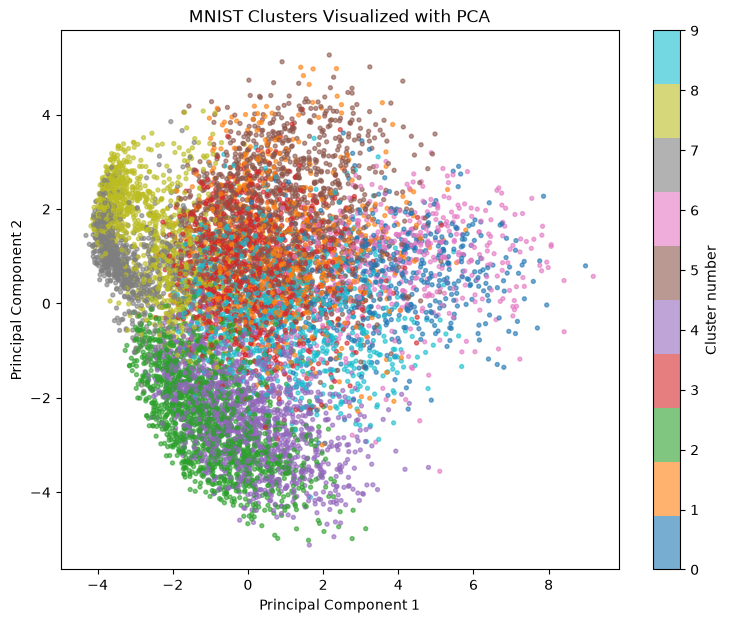

In [24]:
plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Clusters Visualized with PCA")
plt.colorbar(scatter, label="Cluster number", ticks=range(10))
plt.show()

### Part 5 Answers

1. **Do the clusters appear separated?**  
   They are partly separated, but there are no clear boundaries between all ten clusters. Many colours are mixed near the centre of the plot.

2. **Are some clusters overlapping?**  
Yes. Several clusters overlap in the central area. For example, points from clusters 0, 1, 3, and 9 appear mixed there. This is a two-dimensional view of images that originally had 784 features, so overlap in the plot does not tell us everything about their separation in the original data.

3. **Which groups appear to be more clearly separated?**  
Clusters 2 and 4 are more concentrated toward the lower-left area, while clusters 7 and 8 are more concentrated toward the upper-left. Clusters 0 and 6 extend farther to the right. These groups still overlap with other clusters.

4. **Does the PCA visualization support what you observed from the cluster images?**  
Yes. The cluster images showed some recognizable groups and some mixed groups. The PCA plot also shows areas where one or two clusters are more concentrated, alongside a large area where clusters overlap. This is consistent with the Part 4 table, which showed that some clusters contained several actual digits.

## Part 6 — Predict the Cluster of New Images

I will select ten MNIST images that were not in the K-Means training sample and assign each one to a cluster.

#### Select unused images and predict

In [25]:
unused_indices = np.setdiff1d(np.arange(len(X)), sample_indices)
new_indices = unused_indices[:10]

X_new = X[new_indices]
y_new = y[new_indices]  # Used only to interpret the results

new_clusters = kmeans.predict(X_new)

print("Number of new images:", len(X_new))
print("Predicted clusters:", new_clusters)

Number of new images: 10
Predicted clusters: [0 0 0 8 1 7 3 7 0 3]


### Display the New Images and Their Assigned Clusters

#### Display all ten images

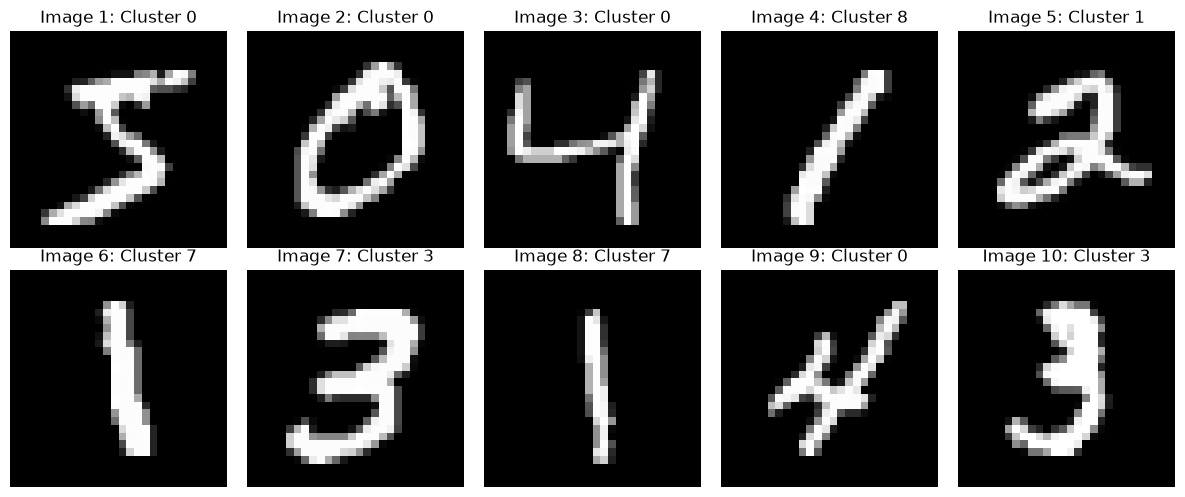

In [26]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_new[i].reshape(28, 28), cmap="gray")
    plt.title(f"Image {i + 1}: Cluster {new_clusters[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#### Show the assignments in a table

In [27]:
new_results = pd.DataFrame({
    "Image": range(1, 11),
    "Predicted cluster": new_clusters,
    "Actual digit": y_new
})

display(new_results)

,Image,Predicted cluster,Actual digit
0,1,0,5
1,2,0,0
2,3,0,4
3,4,8,1
4,5,1,2
5,6,7,1
6,7,3,3
7,8,7,1
8,9,0,4
9,10,3,3


### Part 6 Answers

1. **Which cluster was assigned to each image?**  
   Images 1, 2, and 3 were assigned to cluster 0. Image 4 went to cluster 8; image 5 to cluster 1; image 6 to cluster 7; image 7 to cluster 3; image 8 to cluster 7; image 9 to cluster 0; and image 10 to cluster 3. The table above also shows their actual digit labels.

2. **Do images that look similar receive similar cluster assignments?**  
   Sometimes. Images 6 and 8 are both handwritten 1s and were assigned to cluster 7. Images 7 and 10 are both 3s and were assigned to cluster 3. However, images 1, 2, 3, and 9 represent different digits—5, 0, 4, and 4—but all went to cluster 0.

3. **Are any assignments surprising?**  
   Yes. Cluster 0 contained mostly actual 0s in Part 4 (427 of 519 images), yet new images 1, 3, and 9—labelled 5, 4, and 4—were assigned to it. This shows that a cluster number is not a predicted digit label.

4. **Why might K-Means assign an image to an unexpected cluster?**  
   K-Means assigns each new image to the nearest centroid using its pixel values. The shape, position, or thickness of a handwritten digit may make it closer to a centroid associated mostly with another digit. K-Means does not know the actual digit when making the assignment.

## Part 7 — Final Analysis

1. **What did K-Means discover in the MNIST dataset?**  
K-Means grouped 10,000 handwritten digit images into 10 clusters using their pixel values. Some clusters contained mostly one actual digit, while others contained a mixture. The digit labels were not used to train K-Means.

2. **What value of K did you choose, and why?**  
I chose K = 10. Inertia fell from 432,527.75 at K = 5 to 390,343.06 at K = 10, then to 365,525.23 at K = 15. The reduction became smaller after K = 10. Ten was also a reasonable choice for exploring images of digits 0 through 9, although the model was not given those labels.

3. **What did the cluster centroids tell you?**  
A centroid is the average image of a cluster. Some centroids and their sample images showed a recognizable digit shape, while others looked less clear because their clusters contained different digits or writing styles. The centroid helped me understand the common pixel pattern in each group.

4. **Did the clusters correspond closely to particular digits?**  
Some did, but not all. Cluster 6 contained 458 actual 0s out of 513 images (89.3%), and cluster 1 contained 666 actual 2s out of 757 (88.0%). In contrast, cluster 4 was mixed: it contained 503 images of digit 9, 500 of digit 4, and 295 of digit 7.

5. **Which digits were difficult to separate?**  
Digits 4, 7, and 9 were difficult to separate in this result. They appeared together in clusters 2 and 4. Digits 5 and 8 were also mixed in cluster 3, which contained 266 images of digit 5 and 560 of digit 8. Differences in handwriting can make their pixel shapes look similar.

6. **What did the PCA visualization show?**  
PCA reduced the 784 pixel features to two dimensions for plotting. Some clusters were concentrated in particular areas: clusters 2 and 4 appeared more toward the lower-left, while clusters 7 and 8 appeared more toward the upper-left. Many colours overlapped near the centre, so the groups were not completely separated in the two-dimensional plot.

7. **What are some limitations of using K-Means for handwritten digit images?**  
K-Means compares pixel values rather than understanding the meaning of a digit. Changes in handwriting, size, position, and line thickness can affect the grouping. A digit can appear in several clusters: for example, digit 0 appeared prominently in both clusters 0 and 6. Choosing K = 10 also did not make each cluster match one digit.

8. **How is this project different from Project 3, where you used supervised learning?**  
In Project 3, the models were trained with known Buy, Hold, and Sell target labels. In this project, K-Means was trained on image pixels without the actual digit labels. I used the digit labels only after clustering to understand what the groups contained.